# Supplementary Figure S2(A) — Identification recall & precision by LW class

PARSE vs DSSR identification agreement, per LW class.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

_ROOT = Path.cwd().parent.parent
FIGURES = _ROOT / "figures"

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / name

In [2]:
CWW_CANON_SEQS = {"GC", "CG", "AU", "UA"}


CLASS_ORDER = ["cWW (canon)", "cWW (non-canon)", "tWW", "cWH", "tWH", "cWS",
               "tWS", "cHH", "tHH", "cHS", "tHS", "cSS", "tSS"]


NONCWW_ORDER = ["tWW", "cWH", "tWH", "cWS", "tWS", "cHH", "tHH", "cHS", "tHS", "cSS", "tSS"]


def _canon_lw(lw):
    """Normalize an LW class to canonical face order (W < H < S)."""
    if not lw or len(lw) < 3:
        return lw
    o = {"W": 0, "H": 1, "S": 2}
    return lw[0] + lw[2] + lw[1] if o.get(lw[1], 0) > o.get(lw[2], 0) else lw


def _n_dssr_dotted(diffs):
    """python_only extras where DSSR's own edge label is undetermined ('.')."""
    n = 0
    for d in diffs:
        if d["source"] != "python_only":
            continue
        r = d.get("reason") or ""
        if (r.startswith("dssr_assigns:") and "." in r.split(":", 1)[1]) \
                or "." in (d.get("dssr_lw_class") or ""):
            n += 1
    return n


def _cww_split_metrics(cww_data, canonical):
    s = cww_data["summary"]
    diffs = cww_data["differences"]
    mbs = s["matched_by_sequence"]
    keep = (lambda q: q in CWW_CANON_SEQS) if canonical else (lambda q: q not in CWW_CANON_SEQS)
    matched = sum(v for k, v in mbs.items() if keep(k))
    dssr_only = [d for d in diffs if d["source"] == "dssr_only" and keep(d["sequence"])]
    py_only = [d for d in diffs if d["source"] == "python_only" and keep(d["sequence"])]
    total_dssr = matched + len(dssr_only)
    total_python = matched + len(py_only)
    cc = matched
    for d in dssr_only:
        r = d["reason"] or ""
        if r == "not_selected":
            cc += 1
        elif r.startswith("python_assigns:"):
            a = r.split(":", 1)[1]
            if "|" in a and "cWW" in [_canon_lw(p) for p in a.split("|")]:
                cc += 1
    mis = sum(1 for d in py_only if (d["reason"] or "").startswith("dssr_assigns:")
              and "." not in d["reason"].split(":", 1)[1]
              and _canon_lw(d["reason"].split(":", 1)[1]) != "cWW")
    return {
        "recall_sel": matched / total_dssr if total_dssr else 0,
        "recall_cls": cc / total_dssr if total_dssr else 0,
        "prec_sel": matched / total_python if total_python else 0,
        "prec_cls": cc / (cc + mis) if (cc + mis) else 0,
        "total_dssr": total_dssr, "total_python": total_python, "matched": matched,
    }


def build_metrics():
    """Return (metrics dict keyed by CLASS_ORDER, CLASS_ORDER list)."""
    cww_data = json.load(open(data_file("comparison/cWW.json")))
    noncww_dir = data_file("comparison")
    noncww = {f.stem: json.load(open(f)) for f in sorted(Path(noncww_dir).glob("*.json")) if f.stem != "cWW"}

    metrics = {
        "cWW (canon)": _cww_split_metrics(cww_data, True),
        "cWW (non-canon)": _cww_split_metrics(cww_data, False),
    }
    for lw in NONCWW_ORDER:
        s = noncww[lw].get("summary", noncww[lw])
        cc, mis = s["classified_correct"], s["classified_misclassified"]
        mis_f = mis - _n_dssr_dotted(noncww[lw]["differences"])
        metrics[lw] = {
            "recall_sel": s["recall"], "recall_cls": s["classified_recall"],
            "prec_sel": s["precision"],
            "prec_cls": cc / (cc + mis_f) if (cc + mis_f) else 0,
            "total_dssr": s["total_dssr_pairs"], "total_python": s["total_python_pairs"],
            "matched": s["matched"],
        }
    return metrics, CLASS_ORDER

In [3]:
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})
metrics, CLASS_ORDER = build_metrics()

saved figures/figS2_A_identification_recall_precision.png


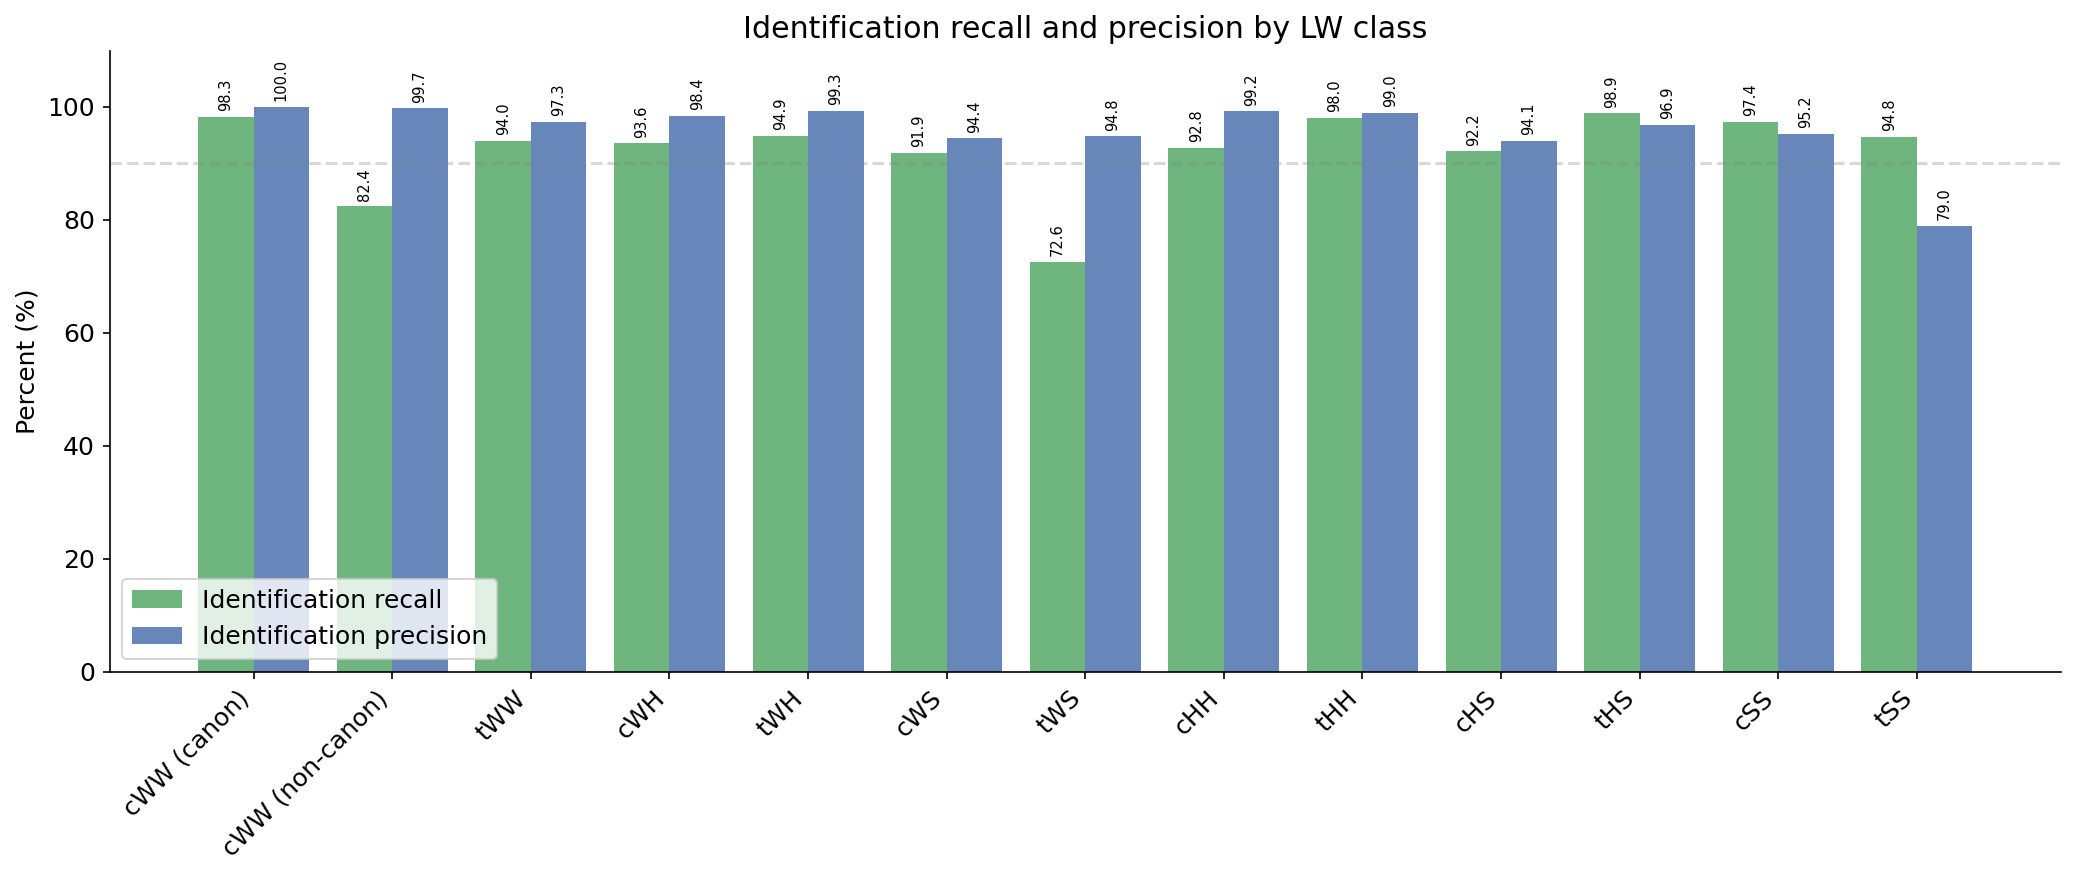

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(CLASS_ORDER)); width = 0.4
recall_cls = [metrics[c]['recall_cls'] * 100 for c in CLASS_ORDER]
prec_cls   = [metrics[c]['prec_cls']   * 100 for c in CLASS_ORDER]
bars_r = ax.bar(x - width/2, recall_cls, width, label='Identification recall',    color='#55A868', alpha=0.85)
bars_p = ax.bar(x + width/2, prec_cls,   width, label='Identification precision', color='#4C72B0', alpha=0.85)
ax.set_ylabel('Percent (%)')
ax.set_title('Identification recall and precision by LW class')
ax.set_xticks(x); ax.set_xticklabels(CLASS_ORDER, rotation=45, ha='right')
ax.set_ylim(0, 110)
ax.legend(loc='lower left')
ax.axhline(y=90, color='gray', linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
for bars in (bars_r, bars_p):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 1, f'{h:.1f}',
                ha='center', va='bottom', fontsize=7, rotation=90)
fig.tight_layout()
print('saved', savefig(fig, 'figS2_A_identification_recall_precision.png'))